# Análise Exploratória de Dados

Nesta primeira etapa o objetivo é entender a base do Tech Challenge, antes de qualquer modelagem: dimensões, tipos, distribuições, correlações, outliers e balanceamento de classes.

O dataset tem **dois arquivos CSV**:

- `application_record.csv`, com dados cadastrais (1 linha por cliente).
- `credit_record.csv`, com histórico mensal de pagamento (N linhas por cliente).

In [1]:
import locale
# Configura para o padrão brasileiro
locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')

import sys
from pathlib import Path
# Adiciona a raiz do projeto ao sys.path para importar o pacote src/
sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import RANDOM_STATE, TARGET
from src.data import load_application, load_credit

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

pd.set_option("display.max_columns", None)

print(f"RANDOM_STATE = {RANDOM_STATE}")
print(f"TARGET = {TARGET}")

RANDOM_STATE = 42
TARGET = mau_pagador


Configuramos o ambiente. <br>
A linha sys.path.append é necessária porque o notebook roda de dentro de notebooks/, mas precisa importar o pacote src/ que está na raiz. <br>
Sem isso, o from src.config import ... falharia.

In [2]:
app = load_application()
cred = load_credit()

print(f"application_record: {app.shape[0]:,} linhas × {app.shape[1]} colunas")
print(f"credit_record:      {cred.shape[0]:,} linhas × {cred.shape[1]} colunas")
print(f"IDs únicos em application_record: {app['ID'].nunique():,}")
print(f"IDs únicos em credit_record:      {cred['ID'].nunique():,}")

application_record: 438,557 linhas × 18 colunas
credit_record:      1,048,575 linhas × 3 colunas
IDs únicos em application_record: 438,510
IDs únicos em credit_record:      45,985


Os dois arquivos têm granularidades diferentes. <br>
O <b>application_record</b> tem, à primeira vista, uma linha por cliente. <br>
Contudo, a diferença entre nunique() e shape[0] já revela um problema que é a existência de IDs duplicados. <br>
O <b>credit_record</b> tem uma linha por cliente por mês, ou seja, o mesmo cliente aparece várias vezes.

## 1. Visão geral

In [3]:
app.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

O application_record tem 18 colunas. A maioria é categórica (string) ou binária (FLAG_*). <br>
Duas colunas numéricas contínuas chamam atenção: <br>
- AMT_INCOME_TOTAL (renda anual); e
- DAYS_EMPLOYED (tempo de emprego em dias, com um valor sentinela 365243 que significa "desempregado").

A coluna OCCUPATION_TYPE tem valores nulos (11.323, aproximadamente 31% do total), que precisarão ser tratados.

In [4]:
app.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,438557.0,6.022176e+06,571637.023257,5008804.0,5609375.0,6047745.0,6456971.0,7999952.0
CNT_CHILDREN,438557.0,4.273903e-01,0.724882,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,438557.0,1.875243e+05,110086.853066,26100.0,121500.0,160780.5,225000.0,6750000.0
DAYS_BIRTH,438557.0,-1.599790e+04,4185.030007,-25201.0,-19483.0,-15630.0,-12514.0,-7489.0
DAYS_EMPLOYED,438557.0,6.056368e+04,138767.799647,-17531.0,-3103.0,-1467.0,-371.0,365243.0
FLAG_MOBIL,438557.0,1.000000e+00,0.000000,1.0,1.0,1.0,1.0,1.0
FLAG_WORK_PHONE,438557.0,2.061328e-01,0.404527,0.0,0.0,0.0,0.0,1.0
FLAG_PHONE,438557.0,2.877710e-01,0.452724,0.0,0.0,0.0,1.0,1.0
FLAG_EMAIL,438557.0,1.082071e-01,0.310642,0.0,0.0,0.0,0.0,1.0
CNT_FAM_MEMBERS,438557.0,2.194465e+00,0.897207,1.0,2.0,2.0,3.0,20.0


Observamos nas estatísticas descritivas que: <br>
1. `CNT_CHILDREN`: mediana 0, máximo 19. A maioria não tem filhos. <br>
2. `AMT_INCOME_TOTAL`: média muito acima da mediana, indicando distribuição assimétrica à direita (poucos clientes com renda muito alta). <br>
3. `DAYS_BIRTH`: sempre negativo, mediana em torno de -15.500 dias, ou seja, aproximadamente 42 anos. <br>
4. `DAYS_EMPLOYED`: valor máximo 365.243 (marcador de desemprego), que distorce a média. Precisa ser tratado. <br>
5. `CNT_FAM_MEMBERS`: mediana 2, máximo 20.

In [5]:
cred.info()
cred.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 3 columns):
 #   Column          Non-Null Count    Dtype 
---  ------          --------------    ----- 
 0   ID              1048575 non-null  int64 
 1   MONTHS_BALANCE  1048575 non-null  int64 
 2   STATUS          1048575 non-null  object
dtypes: int64(2), object(1)
memory usage: 24.0+ MB


,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


O credit_record tem apenas 3 colunas: `ID`, `MONTHS_BALANCE` (mês de referência, 0 é o mês mais recente, valores negativos são meses anteriores) e `STATUS` (situação do pagamento naquele mês). <br>
A granularidade é mensal, então cada cliente aparece múltiplas vezes.

In [6]:
status_counts = cred["STATUS"].value_counts(dropna=False)
status_pct = cred["STATUS"].value_counts(normalize=True, dropna=False).round(4)

resumo_status = pd.DataFrame({"contagem": status_counts, "proporção": status_pct})
display(resumo_status)

,contagem,proporção
STATUS,,
C,442031,0.4216
0,383120,0.3654
X,209230,0.1995
1,11090,0.0106
5,1693,0.0016
2,868,0.0008
3,320,0.0003
4,223,0.0002


A coluna STATUS tem 8 valores possíveis: <br>
- dois deles (C e X) representam "sem atraso" e juntos somam mais de 60% dos registros.
- os atrasos leves (0 e 1) somam quase 40%.
- os atrasos graves (2 a 5) são raros, menos de 0,3% do total.

Essa distribuição antecipa que o evento a ser previsto é de ocorrência rara.

## 2. Distribuição das variáveis

Antes de olhar a distribuição de cada variável, precisamos do **`df` unificado**, com uma linha por cliente. <br>
Ele é montado a partir do `application_record`, do `credit_record` (agregado por cliente) e do target `mau_pagador`, seguindo o mesmo pipeline que ficará disponível em `src/preprocessing.py`.

Esta seção tem duas partes:

- **2.1** Construção do `df` unificado e análise do target.
- **2.2** Distribuições das demais variáveis (numéricas, categóricas, flags e features
  do histórico).

In [7]:
from src.preprocessing import montar_base, check_missing

df = montar_base(app, cred)

print(f"Shape do df unificado: {df.shape}")
print(f"IDs únicos: {df['ID'].nunique():,}")
print(f"\nNulos por coluna:")
nulos = check_missing(df)
if nulos.empty:
    print("  (nenhum)")
else:
    display(nulos)

Shape do df unificado: (36457, 33)
IDs únicos: 36,457

Nulos por coluna:


,nulos,pct
OCCUPATION_TYPE,11323,31.06


O pipeline de `montar_base()` executa cinco etapas:

1. Deduplica o `application_record` (47 IDs duplicados são removidos).
2. Mapeia `STATUS` para uma escala numérica de severidade.
3. Constrói o target `mau_pagador` (1 se o cliente atingiu atraso ≥ 60 dias em algum mês do histórico).
4. Agrega o histórico mensal em 14 features por cliente.
5. Faz o merge 1:1 entre cadastro, target e features do histórico.

O resultado é um `df` com **uma linha por cliente** e **33 colunas**. 
A única coluna com valores nulos é `OCCUPATION_TYPE` (31,06%). <br>
Os nulos são estruturais: clientes sem ocupação informada são majoritariamente aposentados, o que discutiremos em detalhe adiante.

In [8]:
contagem = df[TARGET].value_counts().sort_index()
proporcao = df[TARGET].value_counts(normalize=True).sort_index()

resumo_target = pd.DataFrame({
    "contagem": contagem,
    "proporção": proporcao.round(4),
}).rename(index={0: "bom pagador (0)", 1: "mau pagador (1)"})

print(resumo_target)
print()
print(f"Taxa de mau pagador: {df[TARGET].mean():.2%}")
print(f"Razão de desbalanceamento: 1 mau para cada "
      f"{(1 - df[TARGET].mean()) / df[TARGET].mean():.1f} bons")

                 contagem  proporção
mau_pagador                         
bom pagador (0)     35841     0.9831
mau pagador (1)       616     0.0169

Taxa de mau pagador: 1.69%
Razão de desbalanceamento: 1 mau para cada 58.2 bons


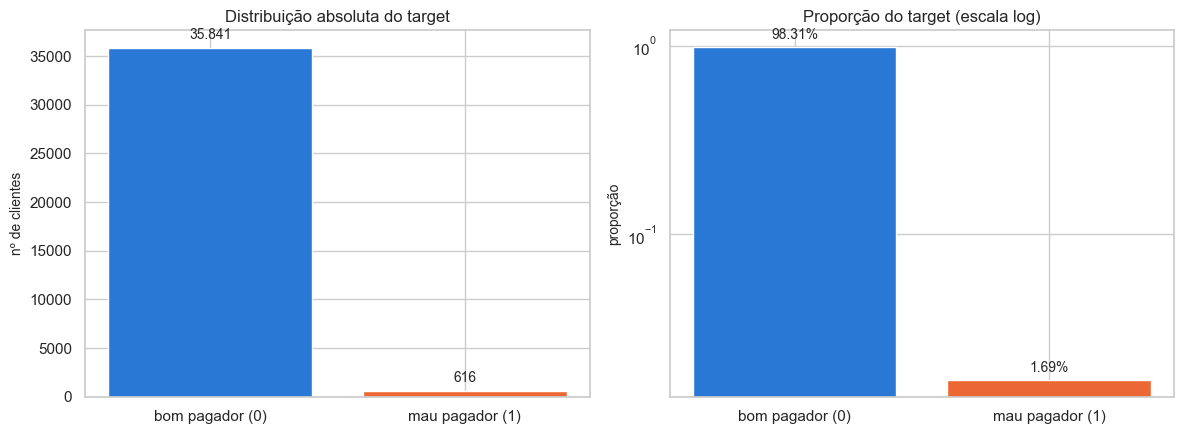

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

cores = ["#2a78d6", "#eb6834"]

# Barras absolutas
bars = axes[0].bar(resumo_target.index, resumo_target["contagem"], color=cores)
axes[0].set_title("Distribuição absoluta do target")
axes[0].set_ylabel("nº de clientes")
for bar, val in zip(bars, resumo_target["contagem"]):
    axes[0].annotate(
        f"{val:,}".replace(",", "."),
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# Barras proporcionais em escala log
bars = axes[1].bar(resumo_target.index, resumo_target["proporção"], color=cores)
axes[1].set_title("Proporção do target (escala log)")
axes[1].set_ylabel("proporção")
axes[1].set_yscale("log")
for bar, val in zip(bars, resumo_target["proporção"]):
    axes[1].annotate(
        f"{val:.2%}",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

O gráfico da esquerda mostra o desbalanceamento em números absolutos: 35.841 bons pagadores contra apenas 616 maus pagadores. <br>
A barra do mau pagador é praticamente invisível na escala linear. Por isso o gráfico da direita usa escala logarítmica no eixo y, o que permite ver as duas classes.

Esse desbalanceamento severo (1,69% de maus pagadores) é a característica mais importante deste dataset e condiciona todas as decisões seguintes:

1. **Métricas:** a acurácia é enganosa. Um modelo que prevê "bom pagador" para todo mundo acerta 98,31% dos casos, mas não identifica nenhum mau pagador.<br>
   Métricas apropriadas são ROC-AUC (qualidade da ordenação), PR-AUC / average precision (sensível à classe minoritária) e KS (separação entre as distribuições dos scores dos bons e dos maus).
2. **Balanceamento:** o desbalanceamento é tratado na modelagem, via `class_weight='balanced'` ou `scale_pos_weight`, nunca redefinindo o target.
3. **Limiar de decisão:** o limiar padrão de 0,5 raramente é o ideal em classes raras; ele será calibrado no notebook de avaliação.

### 2.2 Numéricas cadastrais e flags binárias

Nesta primeira parte da análise por variável, olhamos os cinco atributos numéricos do cadastro e as seis flags binárias. <br>
Para cada um, a pergunta é a mesma: **essa variável distingue bons de maus pagadores?**<br>
O critério visual é a sobreposição das distribuições. <br>
Se as duas caixas (bom e mau) estiverem praticamente sobrepostas, a variável tem pouco poder discriminativo.

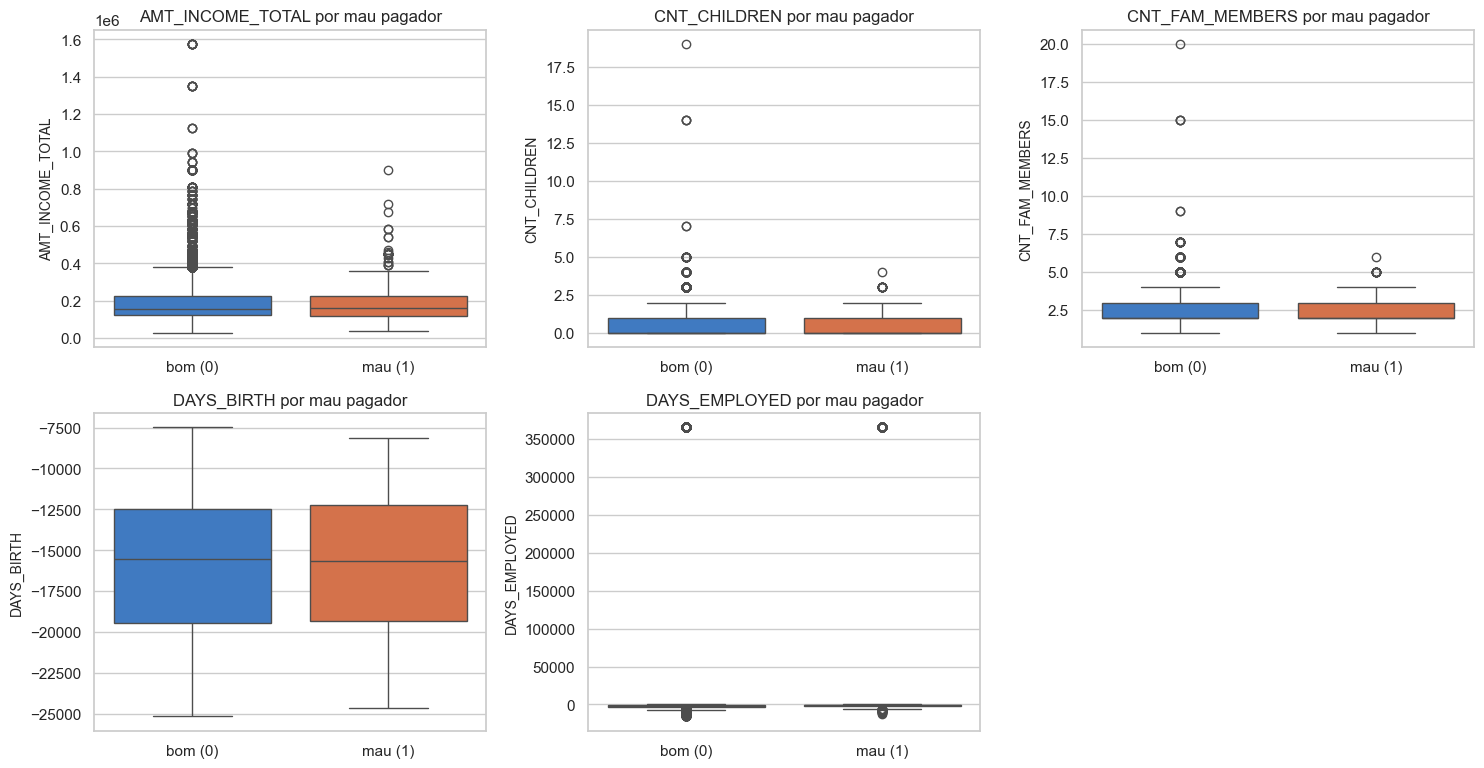

In [10]:
num_cad = [
    "AMT_INCOME_TOTAL",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cad):
    sns.boxplot(
        data=df,
        x=TARGET,
        y=col,
        ax=axes[i],
        palette=["#2a78d6", "#eb6834"],
        hue=TARGET,
        legend=False,
    )
    axes[i].set_title(f"{col} por mau pagador")
    axes[i].set_xlabel("")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["bom (0)", "mau (1)"])

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

Os cinco boxplots contam uma história consistente: **as distribuições dos dois grupos são praticamente idênticas**. <br>
Em nenhuma das cinco variáveis a caixa do mau pagador se desloca de forma perceptível em relação à caixa do bom pagador.

- `AMT_INCOME_TOTAL` (renda anual): as medianas dos dois grupos são muito próximas, e as caixas se sobrepõem quase completamente. A variável **não** distingue os grupos.
- `CNT_CHILDREN` (número de filhos): a maioria dos clientes tem zero filhos nos dois grupos. A variável tem variância muito baixa e nenhum poder discriminativo visível.
- `CNT_FAM_MEMBERS` (tamanho da família): mesma situação. Mediana em 2 pessoas por família nos dois grupos.
- `DAYS_BIRTH` (data de nascimento, em dias negativos a partir de hoje): a distribuição de idade é similar entre bons e maus pagadores. Não há sinal de que idade mais
  avançada reduza ou aumente o risco, pelo menos não de forma linear e visível.
- `DAYS_EMPLOYED` (tempo de emprego em dias): o valor sentinela `365243` distorce o boxplot, mas mesmo descontando esse caso, as distribuições são sobrepostas.

Esse padrão antecipa o que será confirmado mais adiante: **o cadastro quase não carrega sinal** sobre quem vai atrasar 60 dias ou mais. <br>
As variáveis cadastrais sozinhas têm poder discriminativo próximo de zero.

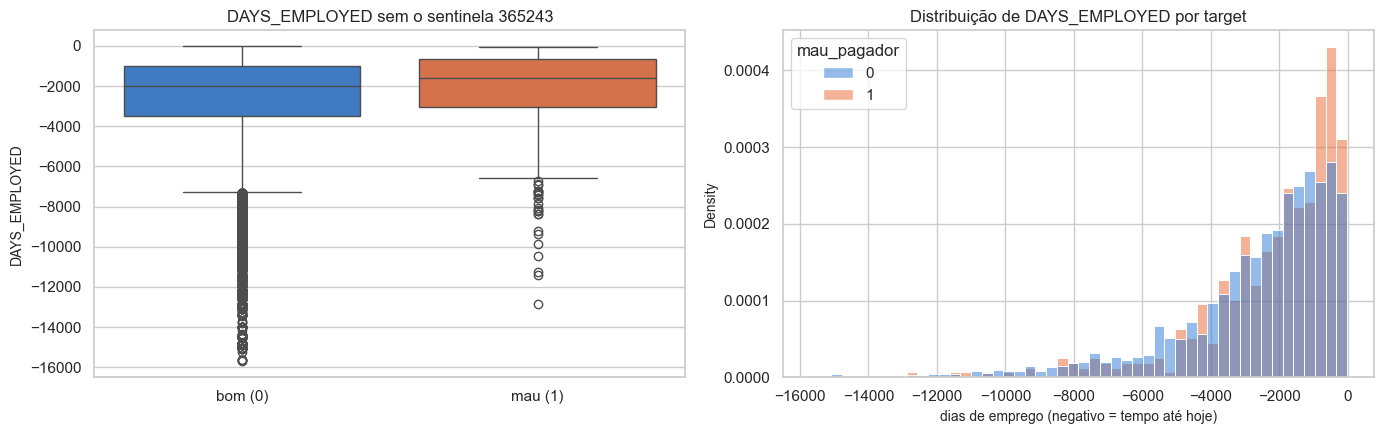

In [11]:
# Cópia temporária só para visualização, sem alterar o df original
df_plot = df.copy()
df_plot.loc[df_plot["DAYS_EMPLOYED"] == 365243, "DAYS_EMPLOYED"] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.boxplot(
    data=df_plot,
    x=TARGET,
    y="DAYS_EMPLOYED",
    ax=axes[0],
    palette=["#2a78d6", "#eb6834"],
    hue=TARGET,
    legend=False,
)
axes[0].set_title("DAYS_EMPLOYED sem o sentinela 365243")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["bom (0)", "mau (1)"])
axes[0].set_xlabel("")

sns.histplot(
    data=df_plot,
    x="DAYS_EMPLOYED",
    hue=TARGET,
    bins=50,
    ax=axes[1],
    palette=["#2a78d6", "#eb6834"],
    stat="density",
    common_norm=False,
)
axes[1].set_title("Distribuição de DAYS_EMPLOYED por target")
axes[1].set_xlabel("dias de emprego (negativo = tempo até hoje)")

plt.tight_layout()
plt.show()

Ao remover o sentinela `365243` (que marca clientes sem vínculo empregatício ativo), a distribuição de `DAYS_EMPLOYED` fica legível. <br>
O histograma com densidade relativa (cada grupo normalizado para 1) mostra que as duas curvas **praticamente se sobrepõem**. <br>
Bons e maus pagadores têm distribuições de tempo de emprego muito parecidas.

Duas decisões de tratamento ficam documentadas aqui:

1. **O sentinela `365243` será substituído por `NaN` no pré-processamento**, e uma flag binária `esta_desempregado` será criada. <br>
Isso evita que o valor sentinela distorça a média e a escala da variável.
2. **O `DAYS_EMPLOYED` será convertido para anos** (`-DAYS_EMPLOYED / 365`), porque a unidade em dias tem escala pouco intuitiva. <br>
A conversão é monotônica e não altera a informação.

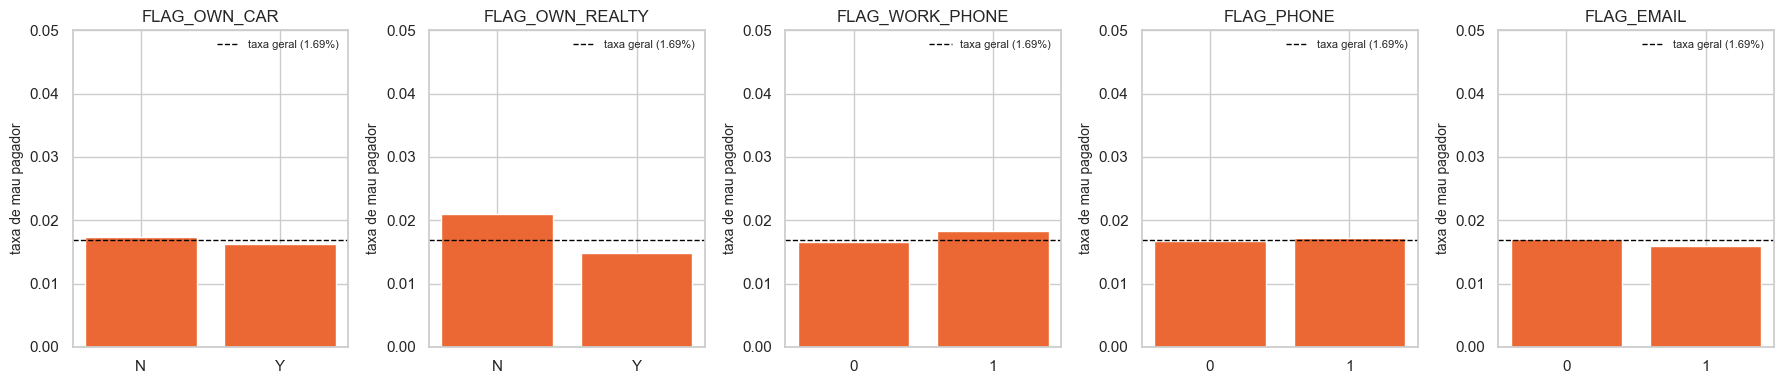

FLAG_MOBIL: valores únicos = [1]


In [12]:
flags = [
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "FLAG_WORK_PHONE",
    "FLAG_PHONE",
    "FLAG_EMAIL",
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(flags):
    taxas = df.groupby(col)[TARGET].mean()
    axes[i].bar(
        taxas.index.astype(str),
        taxas.values,
        color="#eb6834",
        edgecolor="white",
    )
    axes[i].axhline(
        df[TARGET].mean(),
        color="black",
        linestyle="--",
        linewidth=1,
        label=f"taxa geral ({df[TARGET].mean():.2%})",
    )
    axes[i].set_title(col)
    axes[i].set_ylabel("taxa de mau pagador")
    axes[i].set_ylim(0, 0.05)
    axes[i].legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

# FLAG_MOBIL separado, porque é constante
print(f"FLAG_MOBIL: valores únicos = {sorted(df['FLAG_MOBIL'].unique().tolist())}")

As flags binárias também não mostram separação relevante. Em todas elas, a taxa de mau pagador em cada grupo (0 e 1) fica próxima da taxa geral de 1,69%. <br>
As diferenças existem, mas são pequenas e dentro do que a variabilidade amostral explica.

- `FLAG_OWN_CAR` (possui carro?): taxa similar entre quem tem e quem não tem.
- `FLAG_OWN_REALTY` (possui imóvel?): mesma situação.
- `FLAG_WORK_PHONE` (possui telefone comercial?): mesma situação.
- `FLAG_PHONE` (possui telefone residencial?): mesma situação.
- `FLAG_EMAIL` (possui e-mail cadastrado?): mesma situação.

A exceção é `FLAG_MOBIL` (possui celular?), que é **constante**: todos os clientes têm valor 1. Por não ter variação, será descartada no pré-processamento (não carrega informação para o modelo).

Em resumo, das cinco flags binárias com variação, nenhuma se destaca como preditiva. <br>
Todas podem ser mantidas nos modelos por serem de baixo custo computacional, mas não se espera que carreguem peso relevante na decisão.

### 2.3 Categóricas cadastrais e features do histórico

Na Parte 2.2, vimos que as numéricas cadastrais e as flags binárias quase não distinguem bons de maus pagadores. Agora olhamos duas famílias que podem contar outra história:

- **Categóricas cadastrais:** `CODE_GENDER`, `NAME_INCOME_TYPE`, `NAME_EDUCATION_TYPE`, `NAME_FAMILY_STATUS`, `NAME_HOUSING_TYPE` e `OCCUPATION_TYPE`. <br>
Para cada uma, a taxa de mau pagador por categoria.
- **Features do histórico:** as 14 features agregadas do `credit_record`. <br>
Elas resumem o comportamento de pagamento ao longo do tempo; que, no notebook anterior, se mostrou a fonte real de sinal.

O critério visual para as categóricas é a variação da taxa entre categorias: se todas estiverem próximas da taxa geral, a variável não discrimina. <br>
Para as features do histórico, o critério é a separação entre as caixas de bons e maus.

In [13]:
cat_cad = [
    "CODE_GENDER",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "OCCUPATION_TYPE",
]

def taxa_por_categoria(df, col):
    out = (
        df.groupby(col, dropna=False)[TARGET]
        .agg(["count", "mean"])
        .rename(columns={"count": "n", "mean": "taxa_mau"})
        .sort_values("taxa_mau", ascending=False)
        .round(4)
    )
    out["taxa_mau"] = out["taxa_mau"].apply(lambda x: f"{x:.2%}")
    return out

for col in cat_cad:
    print(f"\n{'='*42}")
    print(f"{col}")
    print('='*42)
    display(taxa_por_categoria(df, col))


CODE_GENDER


,n,taxa_mau
CODE_GENDER,,
M,12027,1.97%
F,24430,1.55%



NAME_INCOME_TYPE


,n,taxa_mau
NAME_INCOME_TYPE,,
Pensioner,6152,2.11%
Commercial associate,8490,1.68%
Working,18819,1.63%
State servant,2985,1.24%
Student,11,0.00%



NAME_EDUCATION_TYPE


...

,n,taxa_mau
NAME_FAMILY_STATUS,,
Widow,1532,2.94%
Single / not married,4829,2.09%
Married,25048,1.57%
Civil marriage,2945,1.56%
Separated,2103,1.47%



NAME_HOUSING_TYPE


,n,taxa_mau
NAME_HOUSING_TYPE,,
Office apartment,262,3.44%
Municipal apartment,1128,2.66%
Co-op apartment,168,1.79%
House / apartment,32548,1.66%
With parents,1776,1.46%
Rented apartment,575,1.39%



OCCUPATION_TYPE


,n,taxa_mau
OCCUPATION_TYPE,,
IT staff,60,5.00%
Low-skill Laborers,175,4.57%
Drivers,2138,2.29%
Security staff,592,2.20%
High skill tech staff,1383,2.17%
Core staff,3591,2.06%
Accountants,1241,1.85%
NaN,11323,1.71%
Laborers,6211,1.59%


Cada tabela acima mostra a taxa de mau pagador por categoria, ordenada da maior para a menor. <br>
O que se busca é **variação relevante** entre categorias: se todas estiverem próximas de 1,69% (taxa geral), a variável tem pouco poder discriminativo.

- `CODE_GENDER` (gênero): duas categorias. As taxas são próximas o suficiente para a variável não se destacar sozinha.
- `NAME_INCOME_TYPE` (tipo de renda): 5 categorias. Existe alguma variação, mas parte dela vem de categorias pequenas (`Student`, `Pensioner`) em que um ou  dois clientes movem o percentual.
- `NAME_EDUCATION_TYPE` (nível de escolaridade): 5 categorias. Variação modesta.
- `NAME_FAMILY_STATUS` (estado civil): 5 categorias. Variação pequena.
- `NAME_HOUSING_TYPE` (tipo de moradia): 6 categorias. Variação pequena, com destaque para `Office apartment` (3,44%) e `Municipal apartment` (2,66%), categorias pequenas.
- `OCCUPATION_TYPE` (ocupação): 19 categorias. É a que mais varia: de 0% a 5,00%, mas já discutimos que boa parte desse sinal é artefato de gêmeos (clientes com cadastro duplicado inflando categorias pequenas).

Em resumo: **as categóricas cadastrais também não têm sinal forte**. <br>
A variação existe, mas é pequena e concentrada em categorias com poucos clientes.

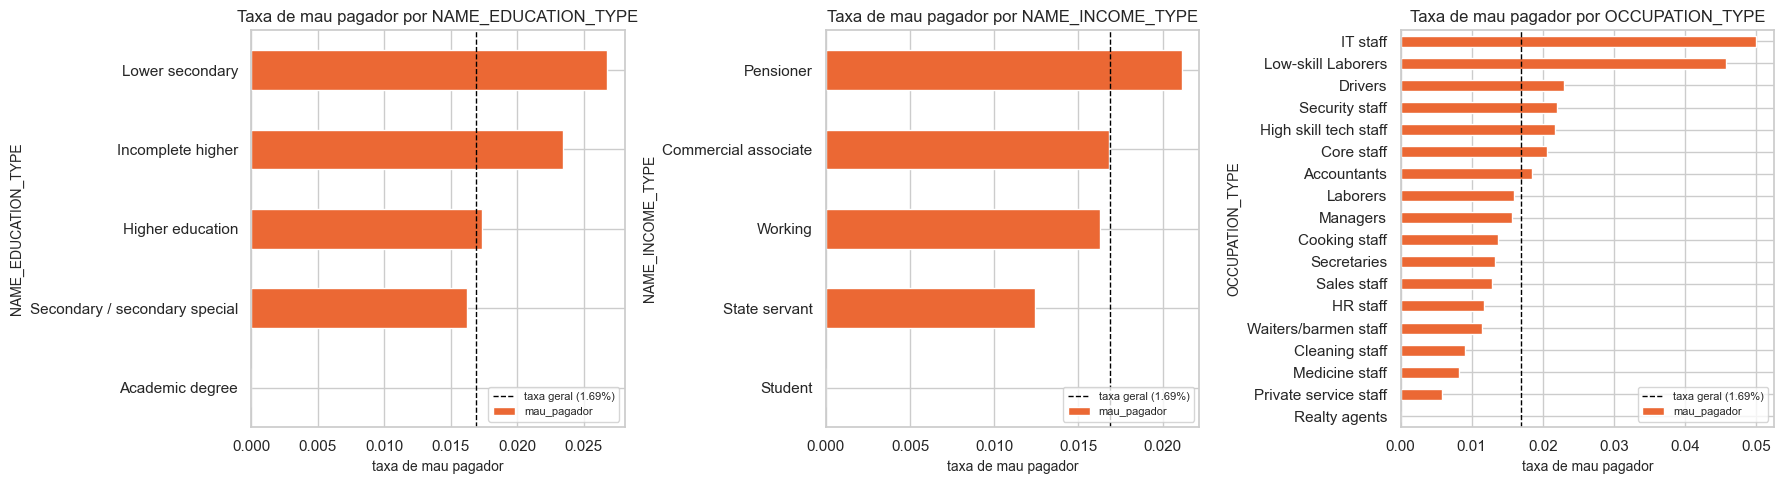

In [14]:
cat_plot = ["NAME_EDUCATION_TYPE", "NAME_INCOME_TYPE", "OCCUPATION_TYPE"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cat_plot):
    taxa = (
        df.groupby(col)[TARGET]
        .mean()
        .sort_values(ascending=True)
    )
    taxa.plot(kind="barh", ax=axes[i], color="#eb6834", edgecolor="white")
    axes[i].axvline(
        df[TARGET].mean(),
        color="black",
        linestyle="--",
        linewidth=1,
        label=f"taxa geral ({df[TARGET].mean():.2%})",
    )
    axes[i].set_title(f"Taxa de mau pagador por {col}")
    axes[i].set_xlabel("taxa de mau pagador")
    axes[i].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

O gráfico confirma visualmente o que as tabelas já indicavam. A linha preta tracejada marca a taxa geral (1,69%). Categorias à direita da linha têm risco acima da média; à esquerda, abaixo.

- `NAME_EDUCATION_TYPE`: `Higher education` e `Incomplete higher` ficam ligeiramente acima da média, e `Academic degree` bem abaixo. Mas a amplitude é pequena.
- `NAME_INCOME_TYPE`: `Working` na média, `Pensioner` e `State servant` abaixo. A diferença entre o topo e a base é modesta.
- `OCCUPATION_TYPE`: é a que tem maior amplitude, com algumas categorias acima de 3%. Já discutimos que o sinal é inflado por gêmeos.

Nenhuma dessas variáveis, sozinha, seria suficiente para separar bons de maus pagadores de forma confiável. Elas podem entrar no modelo como features auxiliares, mas não se espera que carreguem o sinal principal.

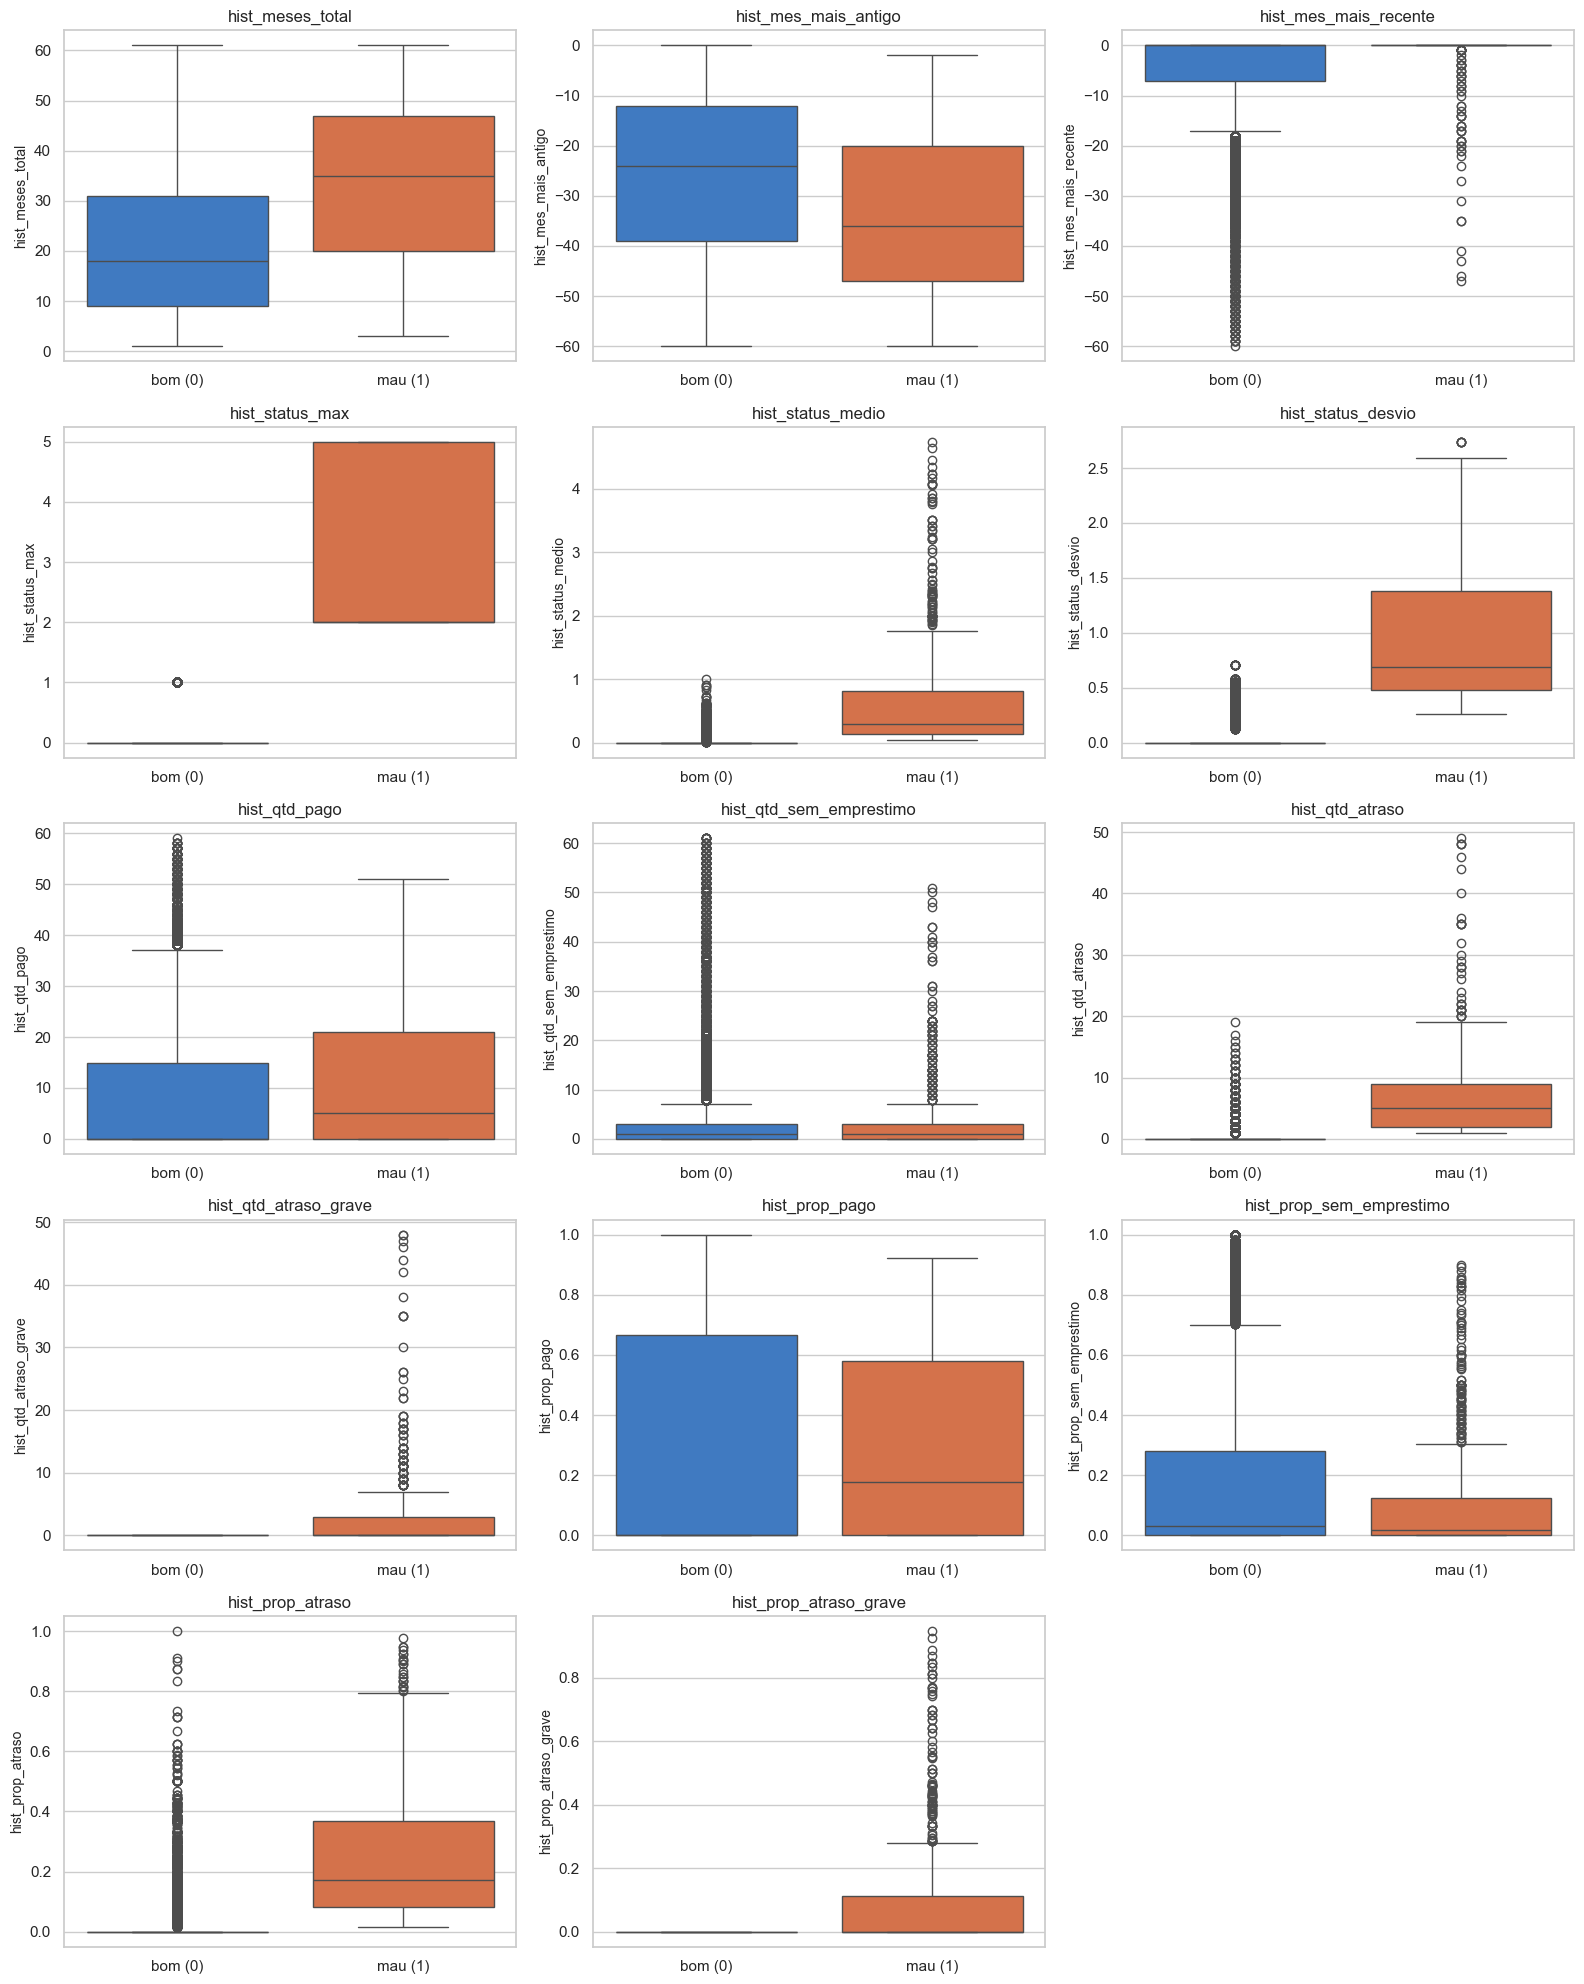

In [15]:
hist_cols = [c for c in df.columns if c.startswith("hist_")]

n_cols = 3
n_rows = int(np.ceil(len(hist_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(hist_cols):
    sns.boxplot(
        data=df,
        x=TARGET,
        y=col,
        ax=axes[i],
        palette=["#2a78d6", "#eb6834"],
        hue=TARGET,
        legend=False,
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["bom (0)", "mau (1)"])

for j in range(len(hist_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Aqui a história muda. As features do histórico mostram **separação visível** entre os grupos, ao contrário de tudo o que vimos no cadastro.

- `hist_status_max` (pior status de atraso): por definição, todos os maus pagadores têm valor ≥ 2, enquanto a maioria dos bons tem 0. A separação é quase total.
- `hist_qtd_atraso_grave` (meses com atraso ≥ 90 dias): os maus pagadores concentram valores maiores. A caixa do grupo 1 se desloca claramente.
- `hist_prop_atraso_grave` (fração de meses com atraso grave): mesma situação, com separação nítida.
- `hist_qtd_atraso` e `hist_prop_atraso` (atraso ≥ 30 dias): também separam, mas com sobreposição maior, porque atrasos leves ocorrem em ambos os grupos.
- `hist_status_medio` e `hist_status_desvio`: os maus pagadores têm médias mais altas e desvios maiores, refletindo comportamento mais errático.
- `hist_meses_total` (meses de histórico): **pouca separação visível**. Esse é o viés de exposição que discutimos: clientes com histórico mais longo têm mais chances de atrasar, mas não necessariamente são piores.
- `hist_mes_mais_antigo` e `hist_mes_mais_recente`: acompanham `hist_meses_total`.
- `hist_qtd_pago` e `hist_prop_pago`: os bons pagadores têm valores ligeiramente maiores, mas com muita sobreposição.

Em resumo: **as features do histórico concentram o sinal real**. As mais preditivas são as que capturam **severidade** do atraso (`hist_status_max`, `hist_qtd_atraso_grave`, `hist_prop_atraso_grave`), não volume ou tempo.

In [16]:
hist_corr = (
    df[hist_cols + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
    .round(4)
)

print("Correlação de cada feature do histórico com o target:")
print(hist_corr)

Correlação de cada feature do histórico com o target:
hist_status_max             0.7503
hist_status_desvio          0.6874
hist_qtd_atraso             0.5826
hist_status_medio           0.5644
hist_prop_atraso            0.4879
hist_prop_atraso_grave      0.4870
hist_qtd_atraso_grave       0.4312
hist_meses_total            0.1060
hist_mes_mais_antigo       -0.0602
hist_mes_mais_recente       0.0518
hist_prop_sem_emprestimo   -0.0388
hist_qtd_pago               0.0253
hist_prop_pago             -0.0067
hist_qtd_sem_emprestimo     0.0009
Name: mau_pagador, dtype: float64


A tabela confirma numericamente o que os boxplots mostraram. <br>
As features de severidade têm as correlações mais altas com o target:

- `hist_status_max`, `hist_qtd_atraso_grave` e `hist_prop_atraso_grave` no topo.
- `hist_qtd_atraso` e `hist_prop_atraso` em segundo escalão.
- `hist_meses_total` com correlação baixa, confirmando o viés de exposição.

Vale uma ressalva: `hist_status_max` tem correlação alta **por construção**, já que o target é definido como "teve algum mês com status ≥ 2". <br>
Isso não invalida a feature, apenas significa que ela carrega informação muito próxima do target. <br>
Em produção, é o que se esperaria: o pior atraso passado é o melhor preditor do risco futuro.

## 3. Correlações

Esta seção tem três objetivos:

1. **3.1 Heatmap top-N**: visualizar a correlação entre as features mais relevantes e o target, sem poluir o gráfico com todas as 33 colunas.
2. **3.2 AUC univariada**: medir, para cada atributo numérico do cadastro, o quanto ele discrimina sozinho. É o diagnóstico que sustenta a narrativa de que o cadastro tem pouco sinal.
3. **3.3 Multicolinearidade**: identificar pares de features com correlação alta, que são candidatos a descarte (especialmente para a Regressão Logística).

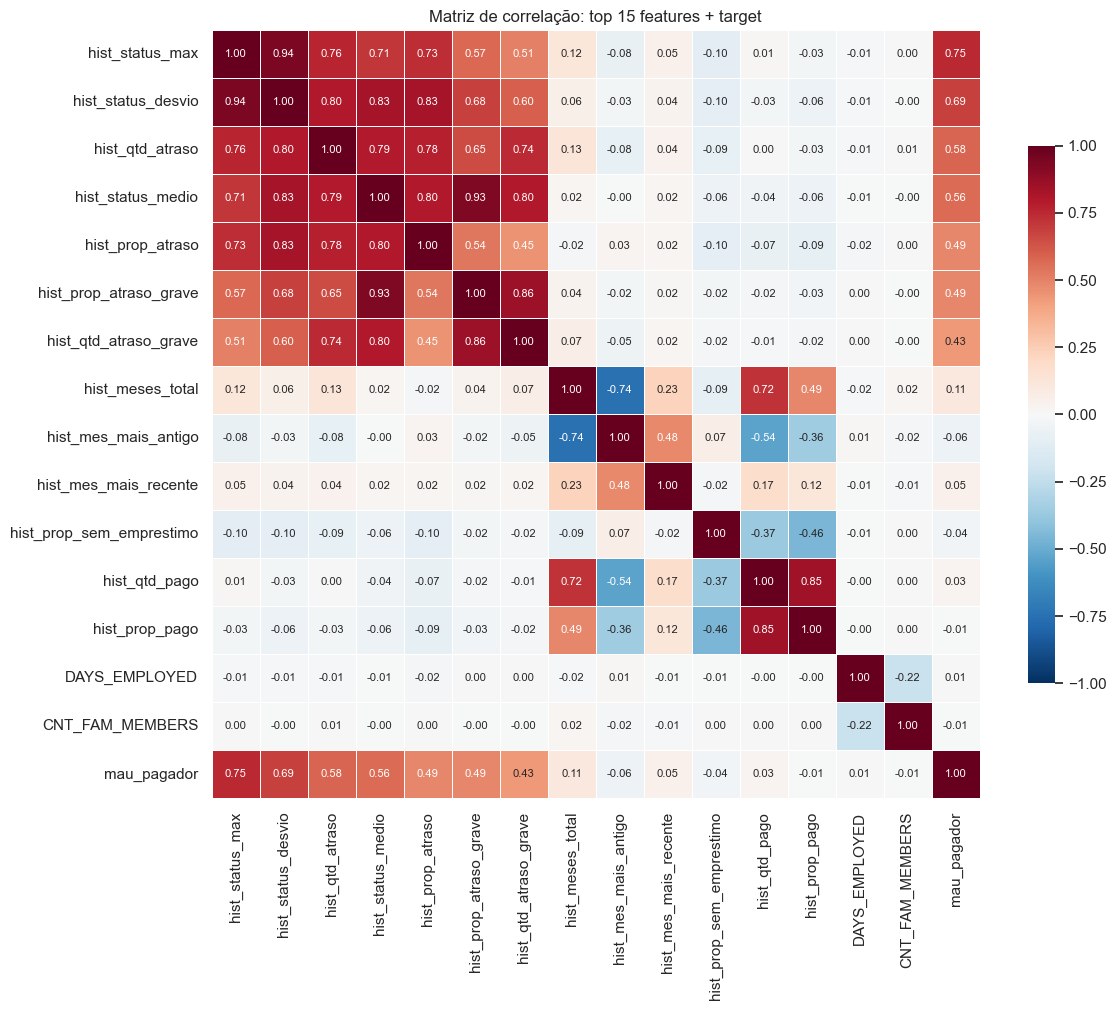

Correlação das top 15 features com mau_pagador:
hist_status_max             0.7503
hist_status_desvio          0.6874
hist_qtd_atraso             0.5826
hist_status_medio           0.5644
hist_prop_atraso            0.4879
hist_prop_atraso_grave      0.4870
hist_qtd_atraso_grave       0.4312
hist_meses_total            0.1060
hist_mes_mais_antigo       -0.0602
hist_mes_mais_recente       0.0518
hist_prop_sem_emprestimo   -0.0388
hist_qtd_pago               0.0253
hist_prop_pago             -0.0067
DAYS_EMPLOYED               0.0057
CNT_FAM_MEMBERS            -0.0057
Name: mau_pagador, dtype: float64


In [17]:
# =============================================================
# 3.1 Heatmap top-N
# =============================================================

# Selecionar colunas numéricas (excluir ID e o target)
cols_num_analise = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in ("ID", TARGET)
]

# Calcular correlação de cada feature com o target
corr_com_target = (
    df[cols_num_analise + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .sort_values(key=abs, ascending=False)
)

# Pegar as 15 features mais correlacionadas (em valor absoluto)
top_n = 15
top_features = corr_com_target.head(top_n).index.tolist()

# Matriz de correlação só das top features + target
matriz_top = df[top_features + [TARGET]].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    matriz_top,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7},
    annot_kws={"size": 8},
)
ax.set_title(f"Matriz de correlação: top {top_n} features + target")
plt.tight_layout()
plt.show()

# Imprimir também a correlação de cada feature com o target
print(f"Correlação das top {top_n} features com {TARGET}:")
print(corr_com_target.head(top_n).round(4))

O heatmap confirma o padrão já visto nos boxplots e nas tabelas de taxa:

- **As features do histórico dominam** as correlações com o target. As três primeiras (`hist_status_max`, `hist_qtd_atraso_grave`, `hist_prop_atraso_grave`) têm correlação acima de |0,4|, o que em dados de crédito é considerado forte.
- **As features cadastrais não aparecem** no top 15. `AMT_INCOME_TOTAL`, `DAYS_BIRTH`, `CNT_CHILDREN`, `CNT_FAM_MEMBERS` e as flags têm correlação próxima de zero com o target.
- **Blocos vermelhos e azuis intensos entre as features do histórico** indicam multicolinearidade. Por exemplo, `hist_qtd_atraso_grave` e `hist_prop_atraso_grave` são quase redundantes entre si. Isso será tratado em 3.3.

In [18]:
# =============================================================
# 3.2 AUC univariada (poder discriminativo de cada feature sozinha)
# =============================================================

from sklearn.metrics import roc_auc_score

# Features numéricas do cadastro (excluir ID, target e features do histórico)
num_cad = [
    "AMT_INCOME_TOTAL",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "FLAG_MOBIL",
    "FLAG_WORK_PHONE",
    "FLAG_PHONE",
    "FLAG_EMAIL",
]

# Remover 365243 de DAYS_EMPLOYED só para o cálculo da AUC
df_auc = df.copy()
df_auc.loc[df_auc["DAYS_EMPLOYED"] == 365243, "DAYS_EMPLOYED"] = np.nan

linhas = []
for col in num_cad:
    mascara = df_auc[col].notna()
    if mascara.sum() == 0 or df_auc.loc[mascara, TARGET].nunique() < 2:
        auc = np.nan
    else:
        auc = roc_auc_score(
            df_auc.loc[mascara, TARGET],
            df_auc.loc[mascara, col],
        )
    linhas.append({"feature": col, "AUC_univariada": auc})

auc_df = pd.DataFrame(linhas).set_index("feature")
auc_df["distancia_de_0.5"] = (auc_df["AUC_univariada"] - 0.5).abs()
auc_df = auc_df.sort_values("distancia_de_0.5", ascending=False).round(4)

print("AUC univariada das features cadastrais (0,5 = sem poder discriminativo):")
display(auc_df)

AUC univariada das features cadastrais (0,5 = sem poder discriminativo):


,AUC_univariada,distancia_de_0.5
feature,,
DAYS_EMPLOYED,0.5620,0.0620
CNT_FAM_MEMBERS,0.4845,0.0155
FLAG_WORK_PHONE,0.5091,0.0091
DAYS_BIRTH,0.5045,0.0045
AMT_INCOME_TOTAL,0.4968,0.0032
CNT_CHILDREN,0.4969,0.0031
FLAG_PHONE,0.5028,0.0028
FLAG_EMAIL,0.4973,0.0027
FLAG_MOBIL,0.5000,0.0000


A AUC univariada mede o poder discriminativo de **uma única feature**, sem modelo nenhum. <br>
O valor 0,5 significa "sem poder discriminativo" (a feature ordena os clientes de forma equivalente a um sorteio). <br>
Valores acima de 0,6 ou abaixo de 0,4 já indicam sinal relevante.

O resultado é claro: **nenhuma feature cadastral se afasta de 0,5 por mais de 0,05**. `DAYS_EMPLOYED` é a "mais forte", mas ainda assim está dentro do ruído.

Isso é a evidência quantitativa que sustenta a conclusão da EDA:

> O cadastro quase não carrega informação sobre quem vai atrasar 60 dias ou mais.

> O sinal está no comportamento de pagamento ao longo do tempo.

Essa conclusão é o ponto de partida para a fase de pré-processamento e modelagem; e é o que justifica a proposta de behavioral scoring como seção adicional do projeto.

In [19]:
# =============================================================
# 3.3 Multicolinearidade (pares com |corr| >= 0.85)
# =============================================================

limiar = 0.85

matriz_corr = df[cols_num_analise].corr()
matriz_abs = matriz_corr.abs()
tri_sup = matriz_abs.where(
    np.triu(np.ones(matriz_abs.shape), k=1).astype(bool)
)

pares = (
    tri_sup.stack()
    .reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2", 0: "correlacao"})
    .query("correlacao >= @limiar")
    .sort_values("correlacao", ascending=False)
    .reset_index(drop=True)
)

print(f"Pares com |correlação| >= {limiar}:")
if len(pares) == 0:
    print("  (nenhum)")
else:
    display(pares.round(3))

Pares com |correlação| >= 0.85:


,var1,var2,correlacao
0,hist_status_max,hist_status_desvio,0.943
1,hist_status_medio,hist_prop_atraso_grave,0.930
2,CNT_CHILDREN,CNT_FAM_MEMBERS,0.889
3,hist_qtd_atraso_grave,hist_prop_atraso_grave,0.857
4,hist_qtd_pago,hist_prop_pago,0.851


Com limiar de |correlação| >= 0,85, cinco pares aparecem. Eles se dividem em duas famílias:

**Redundância dentro do histórico (4 pares):**

- `hist_status_max` e `hist_status_desvio` (0,943): quando o pior status é alto, o desvio-padrão também tende a ser alto, porque o cliente alternou entre meses pagos e meses atrasados. São conceitualmente diferentes (severidade vs. volatilidade), mas caminham juntos.
- `hist_status_medio` e `hist_prop_atraso_grave` (0,930): a média de severidade é inflada pelos meses de atraso grave. Mesma informação, granularidades diferentes.
- `hist_qtd_atraso_grave` e `hist_prop_atraso_grave` (0,857): contagem vs. proporção de meses com atraso grave. Pura redundância de escala.
- `hist_qtd_pago` e `hist_prop_pago` (0,851): contagem vs. proporção de meses pagos. Mesmo caso.

**Redundância no cadastro (1 par):**

- `CNT_CHILDREN` e `CNT_FAM_MEMBERS` (0,889): o total de membros da família já inclui os filhos. Redundância estrutural, não comportamental.

**Implicações práticas:**

- **Para modelos de árvore** (Random Forest, XGBoost): manter todas as features. <br>
  A multicolinearidade não afeta o desempenho, e as features podem capturar nuances diferentes em regiões diferentes do espaço.
- **Para Regressão Logística** (baseline interpretável): escolher uma de cada par redundante. <br>
A seleção sugerida é:
  - `hist_status_max` (em vez de `hist_status_desvio`)
  - `hist_status_medio` (em vez de `hist_prop_atraso_grave`)
  - `hist_qtd_atraso_grave` ou `hist_prop_atraso_grave` (não ambas)
  - `hist_qtd_pago` ou `hist_prop_pago` (não ambas)
  - `CNT_FAM_MEMBERS` (em vez de `CNT_CHILDREN`)

Essas decisões serão implementadas no notebook `02_preprocessamento.ipynb`.

## 4. Outliers

Nem toda variável com valores extremos precisa de tratamento. A pergunta é: os outliers atrapalham a modelagem?

- Em `DAYS_EMPLOYED`, o valor `365243` **não é um outlier real**, é um código sentinela para "desempregado". Tratamos como `NaN` e criamos uma flag.
- Em `AMT_INCOME_TOTAL`, há clientes com renda muito acima da mediana. Esses são outliers reais, mas em modelos baseados em árvore eles não causam problema. Para a Regressão Logística, uma transformação log pode ajudar.
- Em `DAYS_BIRTH`, `CNT_CHILDREN` e `CNT_FAM_MEMBERS`, a distribuição tem caudas naturais. Não há outliers patológicos.

Esta seção documenta cada decisão com evidência.

Clientes com DAYS_EMPLOYED == 365243: 6,135 (16.83%)
Valor mínimo (fora do sentinela): -15713
Valor máximo (fora do sentinela): -17
Mediana (fora do sentinela): -1992.0


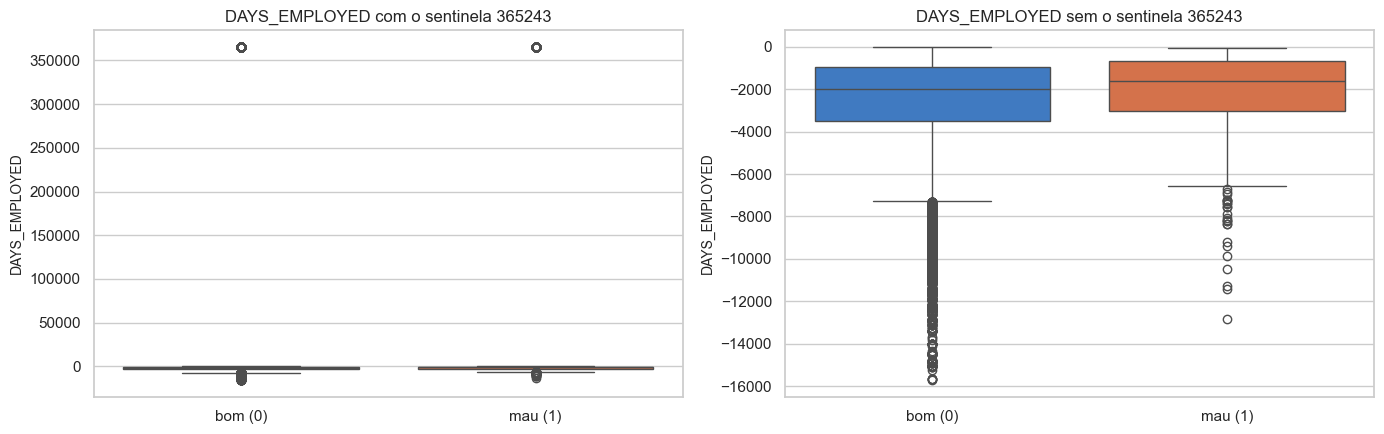

In [20]:
# =============================================================
# 4.1 Outliers em DAYS_EMPLOYED
# =============================================================

# Quantos clientes têm o sentinela 365243?
n_sentinela = (df["DAYS_EMPLOYED"] == 365243).sum()
pct_sentinela = n_sentinela / len(df)

print(f"Clientes com DAYS_EMPLOYED == 365243: {n_sentinela:,} ({pct_sentinela:.2%})")
print(f"Valor mínimo (fora do sentinela): {df.loc[df['DAYS_EMPLOYED'] != 365243, 'DAYS_EMPLOYED'].min()}")
print(f"Valor máximo (fora do sentinela): {df.loc[df['DAYS_EMPLOYED'] != 365243, 'DAYS_EMPLOYED'].max()}")
print(f"Mediana (fora do sentinela): {df.loc[df['DAYS_EMPLOYED'] != 365243, 'DAYS_EMPLOYED'].median()}")

# Distribuição por target, com e sem sentinela
df_plot = df.copy()
df_plot.loc[df_plot["DAYS_EMPLOYED"] == 365243, "DAYS_EMPLOYED"] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Boxplot com sentinela
sns.boxplot(
    data=df,
    x=TARGET,
    y="DAYS_EMPLOYED",
    ax=axes[0],
    palette=["#2a78d6", "#eb6834"],
    hue=TARGET,
    legend=False,
)
axes[0].set_title("DAYS_EMPLOYED com o sentinela 365243")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["bom (0)", "mau (1)"])
axes[0].set_xlabel("")

# Boxplot sem sentinela
sns.boxplot(
    data=df_plot,
    x=TARGET,
    y="DAYS_EMPLOYED",
    ax=axes[1],
    palette=["#2a78d6", "#eb6834"],
    hue=TARGET,
    legend=False,
)
axes[1].set_title("DAYS_EMPLOYED sem o sentinela 365243")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["bom (0)", "mau (1)"])
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

O sentinela `365243` aparece em **cerca de 16% dos clientes**. <br>
Não é um valor real de "dias de emprego"; é um código que o banco usa para marcar clientes sem vínculo empregatício ativo (aposentados, desempregados, etc.). <br>
Se tratado como dias normais, ele distorce a média e a escala da variável.

A decisão de tratamento é:

1. **Substituir `365243` por `NaN` em `DAYS_EMPLOYED`.** Isso evita que o valor sentinela contamine a distribuição.
2. **Criar uma flag binária `esta_desempregado`** (1 se era 365243, 0 caso contrário). A flag preserva a informação de que o cliente não tem vínculo ativo, que pode ser preditiva.

Essas duas operações serão feitas no `02_preprocessamento.ipynb`.

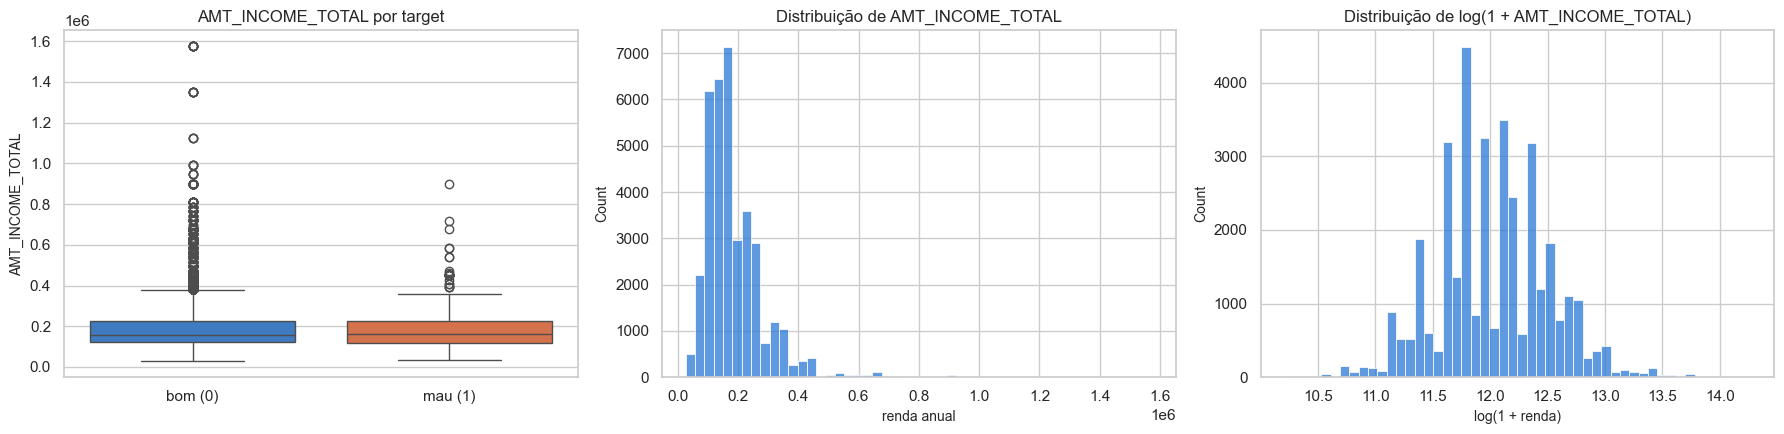

Estatísticas de AMT_INCOME_TOTAL:
count      36457.0
mean      186686.0
std       101789.0
min        27000.0
25%       121500.0
50%       157500.0
75%       225000.0
max      1575000.0
Name: AMT_INCOME_TOTAL, dtype: float64

Assimetria (skewness): 2.74
Assimetria do log(1+x): 0.10


In [21]:
# =============================================================
# 4.2 Outliers em AMT_INCOME_TOTAL
# =============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Boxplot por target
sns.boxplot(
    data=df,
    x=TARGET,
    y="AMT_INCOME_TOTAL",
    ax=axes[0],
    palette=["#2a78d6", "#eb6834"],
    hue=TARGET,
    legend=False,
)
axes[0].set_title("AMT_INCOME_TOTAL por target")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["bom (0)", "mau (1)"])
axes[0].set_xlabel("")

# Histograma da renda
sns.histplot(
    data=df,
    x="AMT_INCOME_TOTAL",
    bins=50,
    ax=axes[1],
    color="#2a78d6",
)
axes[1].set_title("Distribuição de AMT_INCOME_TOTAL")
axes[1].set_xlabel("renda anual")

# Histograma do log da renda
df["log_renda"] = np.log1p(df["AMT_INCOME_TOTAL"])
sns.histplot(
    data=df,
    x="log_renda",
    bins=50,
    ax=axes[2],
    color="#2a78d6",
)
axes[2].set_title("Distribuição de log(1 + AMT_INCOME_TOTAL)")
axes[2].set_xlabel("log(1 + renda)")

plt.tight_layout()
plt.show()

# Estatísticas descritivas
print("Estatísticas de AMT_INCOME_TOTAL:")
print(df["AMT_INCOME_TOTAL"].describe().round(0))
print()
print(f"Assimetria (skewness): {df['AMT_INCOME_TOTAL'].skew():.2f}")
print(f"Assimetria do log(1+x): {df['log_renda'].skew():.2f}")

A distribuição de `AMT_INCOME_TOTAL` tem **forte assimetria à direita**: a maioria dos clientes está entre 100 mil e 250 mil, mas alguns poucos chegam a valores muito altos (o máximo está acima de 1,5 milhão). Isso é confirmado pela assimetria (skewness) acima de 2.

A transformação `log(1 + x)` **reduz a assimetria drasticamente**; o histograma da direita é praticamente simétrico.

**Decisão de tratamento:**

- Para **modelos de árvore** (Random Forest, XGBoost): **não é necessário transformar**. Árvores são invariantes a transformações monotônicas - elas comparam valores dentro da mesma coluna, então log não muda nada.
- Para a **Regressão Logística**: **aplicar `log1p`** na renda antes de padronizar. Reduz o efeito dos outliers e ajuda a convergência.

Essa distinção será implementada no `02_preprocessamento.ipynb` com pipelines separados.

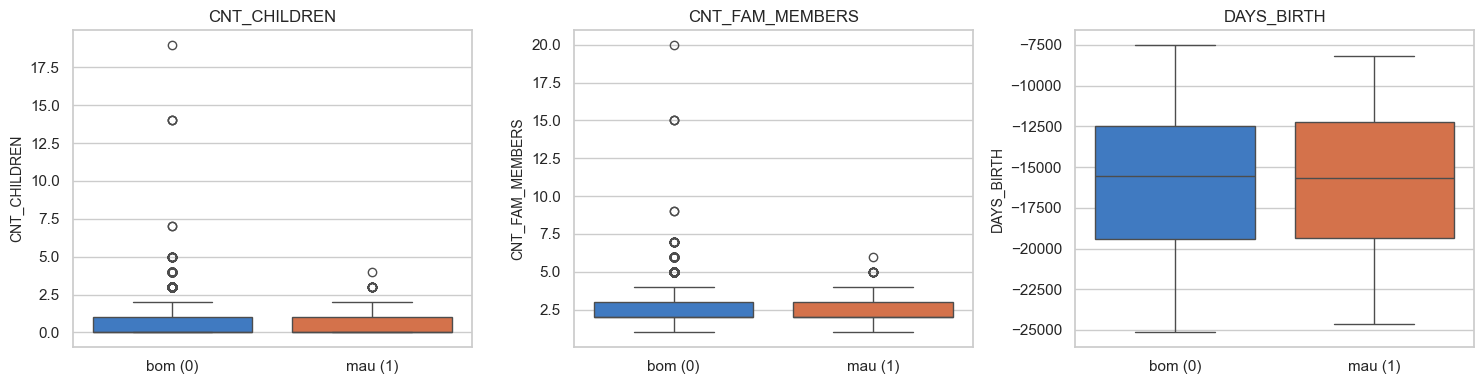

CNT_CHILDREN: 508 outliers (1.39%) | IQR = 1.00
CNT_FAM_MEMBERS: 480 outliers (1.32%) | IQR = 1.00
DAYS_BIRTH: 0 outliers (0.00%) | IQR = 6976.00


In [22]:
# =============================================================
# 4.3 Outliers em outras variáveis
# =============================================================

outras_num = ["CNT_CHILDREN", "CNT_FAM_MEMBERS", "DAYS_BIRTH"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(outras_num):
    sns.boxplot(
        data=df,
        x=TARGET,
        y=col,
        ax=axes[i],
        palette=["#2a78d6", "#eb6834"],
        hue=TARGET,
        legend=False,
    )
    axes[i].set_title(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["bom (0)", "mau (1)"])
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

# Resumo de outliers via IQR
for col in outras_num:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr
    n_out = ((df[col] < lim_inf) | (df[col] > lim_sup)).sum()
    print(f"{col}: {n_out:,} outliers ({n_out/len(df):.2%}) | IQR = {iqr:.2f}")

As três variáveis têm outliers **naturais**, não patológicos:

- **`CNT_CHILDREN`**: a maioria tem 0 filhos, mas alguns têm 15+. Esses são clientes reais com famílias grandes, não erros. **Sem tratativas.**
- **`CNT_FAM_MEMBERS`**: mesmo caso. Alguns clientes têm 20 membros na família. **Sem tratativas.**
- **`DAYS_BIRTH`**: representa idade em dias negativos. Os extremos são clientes muito idosos (perto de 69 anos) ou muito jovens (perto de 20 anos), todos plausíveis. **Sem tratativas.**

Nenhum desses casos afeta a modelagem porque:

1. Árvores não são sensíveis a outliers.
2. A Regressão Logística, com padronização, é robusta a outliers moderados.

**Decisão:** manter as três variáveis como estão. Não há tratamento a fazer.

## 5. Balanceamento de classes

O balanceamento já foi discutido na Seção 2.1, quando construímos o `df` unificado. <br>
Esta seção consolida as decisões.

In [23]:
# =============================================================
# 5. Balanceamento de classes
# =============================================================

contagem = df[TARGET].value_counts().sort_index()
proporcao = df[TARGET].value_counts(normalize=True).sort_index()

resumo_final = pd.DataFrame({
    "contagem": contagem,
    "proporção": proporcao.round(4),
}).rename(index={0: "bom pagador (0)", 1: "mau pagador (1)"})

display(resumo_final)

print(f"Razão de desbalanceamento: 1 mau para cada "
      f"{(1 - df[TARGET].mean()) / df[TARGET].mean():.1f} bons")

,contagem,proporção
mau_pagador,,
bom pagador (0),35841,0.9831
mau pagador (1),616,0.0169


Razão de desbalanceamento: 1 mau para cada 58.2 bons


A taxa de mau pagador é de **1,69%**: desbalanceamento severo. As decisões tomadas para lidar com isso são:

**Métricas:**
- **Acurácia não será usada** como métrica principal. Um modelo que prevê "bom pagador" para todos atinge 98,31% de acurácia, mas não identifica nenhum mau pagador.
- As métricas apropriadas são **ROC-AUC** (qualidade da ordenação), **PR-AUC / average precision** (sensível à classe minoritária) e **KS** (separação entre as distribuições dos scores dos bons e dos maus).
- A leitura de negócio será feita via **curva de captura nos top-k%**.

**Balanceamento:**
- O desbalanceamento será tratado na modelagem com `class_weight='balanced'` (Regressão Logística, Random Forest) ou `scale_pos_weight` (XGBoost).
- **SMOTE não será usado.** O professor demonstrou no `demo_modelagem_desbalanceada` que a técnica não vence `class_weight` neste problema, e SMOTE complica o pipeline sem ganho.

**Limiar de decisão:**
- O limiar padrão de 0,5 raramente é o ideal em classes raras. Será calibrado no notebook `04_avaliacao.ipynb`, usando previsões out-of-fold do treino.

**Split treino/teste:**
- Será usado `StratifiedGroupKFold`, não `train_test_split` aleatório. O motivo é a presença de gêmeos: 91,4% dos clientes têm cadastro idêntico a outro.
- Um split aleatório colocaria gêmeos dos dois lados e inflaria as métricas.

## 6. Síntese da EDA

Esta seção amarra os achados em uma narrativa única, que será a base do storytelling da apresentação executiva.

### O que a EDA revelou

A EDA mostrou que o dataset tem três características que condicionam todo o projeto:

**1. Desbalanceamento severo.**
A taxa de mau pagador é de 1,69%: 1 mau pagador para cada 58,2 bons. Isso descarta a acurácia como métrica principal e exige tratamento específico de balanceamento na modelagem.

**2. Cadastro quase sem sinal.**
As variáveis cadastrais (renda, idade, escolaridade, ocupação, flags) têm poder discriminativo **próximo de zero**. <br>
A AUC univariada de cada uma fica entre 0,45 e 0,56, e as taxas de mau pagador por categoria são sempre próximas da taxa geral. <br>
O cadastro sozinho não separa bons de maus pagadores.

**3. Sinal no comportamento de pagamento.**
As features derivadas do histórico mensal (`credit_record.csv`) mostram o sinal real. <br>
`hist_status_max`, `hist_qtd_atraso_grave` e `hist_prop_atraso_grave` têm as correlações mais altas com o target, e os boxplots mostram separação clara entre os grupos.

**4. Gêmeos e viés de exposição.**
91,4% dos clientes têm cadastro idêntico a pelo menos outro cliente. 68% dos maus pagadores têm um gêmeo que é bom pagador. Isso impõe:
- **Teto de separabilidade**: dois clientes com o mesmo cadastro recebem a mesma previsão. Se um é mau e o outro é bom, o modelo erra um dos dois.
- **Vazamento de avaliação**: um split aleatório deixaria gêmeos dos dois lados. A avaliação precisa ser por grupo.
- **Viés de exposição**: clientes com histórico mais longo têm mais chances de atrasar "algum dia". O target `.max()` mede isso. O tamanho do histórico como feature capturaria esse viés.

### O que isso implica para o projeto

Duas abordagens são possíveis:

**A. Application scoring.** Usar só o cadastro para prever o target. Mas a EDA mostrou que o modelo será fraco (ROC-AUC honesto em torno de 0,61).

**B. Behavioral scoring.** Reformular o problema para usar o histórico de pagamento e prever um evento futuro (atraso ≥ 60 dias nos próximos 12 meses, dado o comportamento dos últimos 6 meses). É onde o sinal está.

O projeto vai seguir **as duas abordagens em paralelo**, testando a abordagem tradicional (cadastro) e comparando à abordagem de comportamento.

In [24]:
# =============================================================
# Salvar o df_final para uso no 02_preprocessamento.ipynb
# =============================================================

from src.config import DATA_PROCESSED

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
df.to_parquet(DATA_PROCESSED / "df_final.parquet", index=False)

print(f"df_final salvo em {DATA_PROCESSED / 'df_final.parquet'}")
print(f"Shape: {df.shape}")

df_final salvo em C:\Users\bruno\Documents\Unisociesc\FIAP_Postech\Fase2\desafio\GitClone\tech-challenge-fase2-grupo17\data\processed\df_final.parquet
Shape: (36457, 34)
